In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import scipy as sp
%matplotlib inline

In [192]:
pd.set_option('display.max_columns', None)

## Load Dataset

Loading `ipl_deliveries.csv` dataset which I downloaded from kaggle. This dataset has the data of every ball which was bowled during a particulqar match

Columns and their significance:  

1. `match_id`: Represents the ID unieuq identifier of the match played.
2. `inning`: Inning represents the inning of the match: 1: 1st inning, 2nd: 2nd Inning, 3rd: 1st Superover, 4: 2nd Superover
3. `batting_team` and `bowling_team`: Shows the respective battng and bowling teams
4. `over` and `ball`: Represenjts the current over and ball respectively
5. `batsman` and `non_striker`: the batsman facing the bowled ball and batsman at the non-striker end.
6. `bowler`: the bowler bowling the ball
7. `is_super_over`: 1 if super_over else 0
8. wide_runs, `bye_runs`, `legbye_runs`, `noball_runs`, `penalty_runs`, `extra_runs`: Extra runs earned by the batting team.
9. `batsman_runs` and `total_runs`: runs batsman scored on that ball and total runs batting team earned when extra runs were added
10. `player_dismissed` and `dismissal_kind`: Played dismissed on that ball, else not out, the method of dismissal (ex: Bowled, Caught, Run out, etc.)
11. `fielder`: fielder who caught the ball which led to the dismissal.

In [193]:
dataset = pd.read_csv("ipl_deliveries.csv")

In [194]:
dataset.head()

# display(dataset['inning'].value_counts())

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN


In [195]:
dataset.isna().sum()
delivery_dataset = dataset.copy()

### Filling Missing values

I observed there were missing values in three columns: I started replacing NaN from `dismissal_kind` with 'not out' where the player was not dismisse and 'N/A' for `dismissal_kind` and `fielder` for the same.



In [196]:
### Filling in missing values: in player_dismissed, dismissal_kind, fielder.

delivery_dataset['player_dismissed'] = delivery_dataset['player_dismissed'].fillna('not out')

delivery_dataset['dismissal_kind'] = delivery_dataset['dismissal_kind'].fillna('N/A')

delivery_dataset['fielder'] = delivery_dataset['fielder'].fillna('N/A')

### Dropping Duplicates

note: there were no duplicated rows in the deliveries dataset

In [197]:
# display(delivery_dataset.loc[delivery_dataset.duplicated().sum()])
print(f"Number of duplicated rows before: {delivery_dataset.duplicated().sum()}")

print(f"Number of duplicated rows after: {delivery_dataset.duplicated().sum()}")

Number of duplicated rows before: 0
Number of duplicated rows after: 0


In [198]:
delivery_dataset.head()

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
1,1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
2,2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,not out,N/A,N/A
3,3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
4,4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,not out,N/A,N/A


### Standardising Team Names:

Some team names were duplicated ('Rising Pune Supergiants' : 'Rising Pune Supergiant') and some team officially changed thier names ex. Delhi and Punjab team. So I defined a function that will standardize their name to current name or keep one name if duplicates exists. This is done in order to avoid confusion when plotting graphs and gathering insights

In [199]:
all_teams = np.unique(delivery_dataset['batting_team'])

print(f"Teams before standardising names: {len(all_teams)}")
display(all_teams)

same_team_names = {
    'Rising Pune Supergiants' : 'Rising Pune Supergiant',
    'Delhi Daredevils' : 'Delhi Capitals',
    'Deccan Chargers' : 'Sunrisers Hyderabad',
    'Kings XI Punjab' : 'Punjab Kings'
}

## Function to standardised team name:
def standardised_team_names(df,columns):
    for col in columns:
        df[col] = df[col].replace(same_team_names)
    return df

team_columns = ['batting_team', 'bowling_team']
delivery_dataset = standardised_team_names(delivery_dataset, team_columns)

all_teams = np.unique(delivery_dataset['batting_team'])
print(f"Teams after standardising names: {len(all_teams)}")
display(all_teams)

Teams before standardising names: 14


array(['Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredevils',
       'Gujarat Lions', 'Kings XI Punjab', 'Kochi Tuskers Kerala',
       'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors',
       'Rajasthan Royals', 'Rising Pune Supergiant',
       'Rising Pune Supergiants', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

Teams after standardising names: 12


array(['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions',
       'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians',
       'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

### Finding the batsman stats first:

Here I analysed batsman stats by extracting various matrices from the deliveries dataset: 
This is what I feature engineered in another dataset:

`batsman` `batsman_runs` `no.of_balls` `dismissals_count` `matches_played` `strike_rate` `batting_average` `batting_team` `no_of_fours` `no_of_sixes` `boundary_percentage` `no_of_100s` `no_of_50s`

These metrices were really important for analysing how batsman were playing the IPL and how they dominated.

Note: This is a historical IPL dataset and it has matches played between 2008 and 2019 only, it does not contain anything whcih will let us see the form of a played, their peak season or anything. These features were extracted from the avaialable dataset

=====================================================================================================================================

In [200]:
batsman_team = delivery_dataset.groupby('batsman')['batting_team'].unique()

In [201]:
# Finding the batsman stats first:
# batsman total balls balls
batsman_total_balls = delivery_dataset['batsman'].value_counts().reset_index()
batsman_total_balls.rename(columns={'count':'no.of_balls'}, inplace=True)


# batsman runs
batsman_runs = delivery_dataset.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).reset_index()


#making a new df for batsman and will use this for eda!
batsman_stats = pd.merge(batsman_runs, batsman_total_balls, on='batsman', how='left')


# batsman dismissals
batsman_dismissals = delivery_dataset['player_dismissed'].value_counts().reset_index()
batsman_dismissals.columns = ['batsman', 'dismissals_count']
batsman_dismissals = batsman_dismissals[batsman_dismissals['batsman'] != 'not out']
# merging:
batsman_stats = pd.merge(batsman_stats, batsman_dismissals, on='batsman', how='left')
batsman_stats['dismissals_count'] = batsman_stats['dismissals_count'].fillna(0)

#total matches played.
total_matches_played_by_batsman = delivery_dataset.groupby('batsman')['match_id'].nunique().reset_index()
batsman_stats = pd.merge(batsman_stats, total_matches_played_by_batsman,on='batsman', how='left')
batsman_stats.rename(columns={'match_id':'matches_played'},inplace=True)


#strike rate
batsman_stats['strike_rate'] = (batsman_stats['batsman_runs'] / batsman_stats['no.of_balls'].replace(0,np.nan)) * 100
batsman_stats['strike_rate'] = batsman_stats['strike_rate'].fillna(np.inf)


# batting average
batsman_stats['batting_average'] = batsman_stats['batsman_runs'] / batsman_stats['dismissals_count'].replace(0,np.nan)
batsman_stats['batting_average'] = batsman_stats['batting_average'].fillna(np.inf)


# batsman and played teams
batsman_stats = pd.merge(batsman_stats, batsman_team, on='batsman', how='left')


# bstsman fours and sixes.
batsman_fours = delivery_dataset[delivery_dataset['batsman_runs'] == 4].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_fours.rename(columns={'batsman_runs':'no_of_fours'}, inplace=True)

batsman_sixes= delivery_dataset[delivery_dataset['batsman_runs'] == 6].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_sixes.rename(columns={'batsman_runs':'no_of_sixes'}, inplace=True)

batsman_stats = pd.merge(batsman_stats, batsman_fours, on='batsman', how='left')
batsman_stats = pd.merge(batsman_stats, batsman_sixes, on='batsman', how='left')

batsman_stats['no_of_fours'] = batsman_stats['no_of_fours'].fillna(0).astype(int)
batsman_stats['no_of_sixes'] = batsman_stats['no_of_sixes'].fillna(0).astype(int)


# boundary percentage
batsman_stats['boundary_percentage'] = (
    ((batsman_stats['no_of_fours'] * 4) + (batsman_stats['no_of_sixes'] * 6)) / batsman_stats['batsman_runs'].replace(0,np.nan)) * 100

batsman_stats['boundary_percentage'] = batsman_stats['boundary_percentage'].fillna(0)


##batsman_runs_per_match
batsman_runs_per_match = delivery_dataset.groupby(['match_id','batsman'])['batsman_runs'].sum().reset_index()

def count_hundreds(runs):
    return (runs>=100).sum()

def count_fifties(runs):
    return (runs>=50).sum()

hundreds = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_hundreds).reset_index(name='no_of_100s')
fifties = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_fifties).reset_index(name='no_of_50s')

batsman_stats = pd.merge(batsman_stats, hundreds, on='batsman', how='left')
batsman_stats = pd.merge(batsman_stats, fifties, on='batsman', how='left')

batsman_stats['no_of_100s']= batsman_stats['no_of_100s'].fillna(0).astype(int)
batsman_stats['no_of_50s']= batsman_stats['no_of_50s'].fillna(0).astype(int)

In [202]:
batsman_stats

,batsman,batsman_runs,no.of_balls,dismissals_count,matches_played,strike_rate,batting_average,batting_team,no_of_fours,no_of_sixes,boundary_percentage,no_of_100s,no_of_50s
0,SK Raina,4548,3369,134.0,157,134.995548,33.940299,"[Gujarat Lions, Chennai Super Kings]",402,174,58.311346,1,32
1,V Kohli,4423,3494,118.0,141,126.588437,37.483051,[Royal Challengers Bangalore],384,160,56.432286,4,35
2,RG Sharma,4207,3274,129.0,153,128.497251,32.612403,"[Mumbai Indians, Sunrisers Hyderabad]",354,173,58.331353,1,33
3,G Gambhir,4132,3433,131.0,146,120.361200,31.541985,"[Kolkata Knight Riders, Delhi Capitals]",484,58,55.275895,0,35
4,DA Warner,4014,2902,100.0,114,138.318401,40.140000,"[Sunrisers Hyderabad, Delhi Capitals]",401,160,63.876432,3,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,Abdur Razzak,0,2,0.0,1,0.000000,inf,[Royal Challengers Bangalore],0,0,0.000000,0,0
457,S Kaushik,0,1,1.0,1,0.000000,0.000000,[Gujarat Lions],0,0,0.000000,0,0
458,S Ladda,0,10,1.0,2,0.000000,0.000000,[Delhi Capitals],0,0,0.000000,0,0
459,U Kaul,0,1,0.0,1,0.000000,inf,[Punjab Kings],0,0,0.000000,0,0


### Bowler Stats:

Here I analysed bowlers and their stats by extracting the needed information from the deliveries dataset, which was used to then analysed and feature engineer a dataset:
Features I extracted for analysis are:

`bowler` `runs_conceded` `balls_bowled` `wide_runs` `noball_runs` `bye_runs` `legbye_runs` `penalty_runs` `extra_runs` `no_of_wickets` `bowling_average` `matches_played` `no_of_overs` `dot_balls` `four_plus_wickets` `five_plus_wickets` `bowling_economy` `average_dot_balls` `bowling_strike_rate`

Note: This is a historical IPL dataset and it has matches played between 2008 and 2019 only, it does not contain anything whcih will let us see the form of a played, their peak season or anything. These features were extracted from the avaialable dataset.

In [203]:
#balls bowled by bowler
total_balls_bowled = delivery_dataset['bowler'].value_counts().reset_index()
total_balls_bowled.rename(columns={'count':'balls bowled'},inplace=True)
#total runs conceeded
total_runs_conceeded_by_bowler = delivery_dataset.groupby('bowler')['total_runs'].sum().sort_values(ascending=False).reset_index()
total_runs_conceeded_by_bowler.rename(columns={'total_runs':'runs_conceded'}, inplace=True)

#bowler stats
bowler_stats = pd.merge(total_runs_conceeded_by_bowler,total_balls_bowled,on='bowler', how='left')



# most wides
bowled_most_wide = delivery_dataset.groupby('bowler')['wide_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'wide balls'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_wide, on='bowler', how='left'))

# most no balls
bowled_most_no_balls = delivery_dataset.groupby('bowler')['noball_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'no balls'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_no_balls, on='bowler', how='left'))

#most bye runs
bowled_most_by_runs = delivery_dataset.groupby('bowler')['bye_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'bye runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats,bowled_most_by_runs , on='bowler', how='left'))

# most leg bye
bowled_most_leg_bye = delivery_dataset.groupby('bowler')['legbye_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'leg bye runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_leg_bye , on='bowler', how='left'))

# most penalty runs
bowled_most_penalty_runs = delivery_dataset.groupby('bowler')['penalty_runs'].sum().sort_values(ascending=False).reset_index()
bowled_most_wide.rename(columns={'count':'penalty runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_penalty_runs , on='bowler', how='left'))

# msot extra runs overall
bowled_extra_runs = delivery_dataset.groupby('bowler')['extra_runs'].sum().sort_values(ascending=False).reset_index()
bowled_most_wide.rename(columns={'count':'extra runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats,bowled_extra_runs , on='bowler', how='left'))

#bowler credited wickets
bowler_credited_dismissal = delivery_dataset[
    delivery_dataset['dismissal_kind'].isin(['caught', 'bowled', 'lbw' ,'stumped', 'caught and bowled'])
]

wickets_by_bowler = bowler_credited_dismissal.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False)
wickets_by_bowler = wickets_by_bowler.reset_index()
wickets_by_bowler.rename(columns= {'dismissal_kind':'no_of_wickets'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, wickets_by_bowler, on='bowler', how='left'))
bowler_stats['no_of_wickets'] = bowler_stats['no_of_wickets'].fillna(0).astype(int)

# Bowler stats: bowling_avg, totalmatches, total overs, total dot balls, wicket per match (matchid), four wickets, five wickets, 
# bowling economy, avg  dot balls, bowling SR 
bowler_stats['bowling_average'] = bowler_stats['runs_conceded'] / bowler_stats['no_of_wickets'].replace(0,np.nan)
bowler_stats['bowling_average'] = bowler_stats['bowling_average'].fillna(0)

#total matches played.
total_matches_played_by_bowler = delivery_dataset.groupby('bowler')['match_id'].nunique()
bowler_stats = pd.merge(bowler_stats, total_matches_played_by_bowler,on='bowler', how='left')
bowler_stats.rename(columns={'match_id':'matches_played'},inplace=True)

#total overs
total_overs = delivery_dataset.groupby('bowler')['over'].nunique().reset_index()
total_overs.rename(columns={'over':'no_of_overs'}, inplace=True)
bowler_stats = pd.merge(bowler_stats, total_overs, on='bowler', how='left')

# #total dot balls
total_dot_balls= delivery_dataset[delivery_dataset['total_runs'] == 0].groupby('bowler')['total_runs'].value_counts().reset_index()
total_dot_balls.rename(columns={'count':'dot balls'},inplace=True)
bowler_stats = pd.merge(bowler_stats, total_dot_balls, on='bowler',how='left')
bowler_stats.drop(columns=['total_runs'],axis=1)
bowler_stats['dot balls'] = bowler_stats['dot balls'].fillna(0).astype(int)

# #bowler wickets per match  
bowler_wickets_per_match = bowler_credited_dismissal.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index()
bowler_wickets_per_match.rename(columns={'dismissal_kind':'wickets_in_match'},inplace=True)


# #4 and 5 wickets haul
four_wicks_haul = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 4].groupby('bowler')['match_id'].count().reset_index(name='four_plus_wickets')
five_wicks_haul = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 5].groupby('bowler')['match_id'].count().reset_index(name='five_plus_wickets')
bowler_stats = pd.merge(bowler_stats,four_wicks_haul,on='bowler', how='left')
bowler_stats = pd.merge(bowler_stats,five_wicks_haul,on='bowler', how='left')

bowler_stats['four_plus_wickets'] = bowler_stats['four_plus_wickets'].fillna(0).astype(int)
bowler_stats['five_plus_wickets'] = bowler_stats['five_plus_wickets'].fillna(0).astype(int)


# bowline_economy
bowler_stats['bowling_economy'] = bowler_stats['runs_conceded'] / bowler_stats['no_of_overs'].replace(0,np.nan)
bowler_stats['bowling_economy'] = bowler_stats['bowling_economy'].fillna(np.inf)

#avg dot balls
bowler_stats['average_dot_balls'] = ((bowler_stats['dot balls']/bowler_stats['balls bowled']) * 100).replace(0,np.nan)
bowler_stats['average_dot_balls'] = bowler_stats['average_dot_balls'].fillna(np.inf)

#bowling strike rate
bowler_stats['bowling_strike_rate'] = bowler_stats['balls bowled'] / bowler_stats['no_of_wickets'].replace(0, np.nan)
bowler_stats['bowling_strike_rate'] = bowler_stats['bowling_strike_rate'].fillna(np.inf)

bowler_stats = bowler_stats.drop(columns=['total_runs'], axis=1)

In [204]:
display(bowler_stats.head(20))

display(bowler_stats.isna().sum())

,bowler,runs_conceded,balls bowled,wide_runs,noball_runs,bye_runs,legbye_runs,penalty_runs,extra_runs,no_of_wickets,bowling_average,matches_played,no_of_overs,dot balls,four_plus_wickets,five_plus_wickets,bowling_economy,average_dot_balls,bowling_strike_rate
0,Harbhajan Singh,3453,2989,87,3,13,55,0,158,126,27.404762,134,20,1062,2,1,172.650000,35.530278,23.722222
1,P Kumar,3342,2637,144,1,5,86,0,236,90,37.133333,119,20,1075,0,0,167.100000,40.766022,29.300000
2,PP Chawla,3315,2594,62,1,16,38,0,117,126,26.309524,128,19,910,2,0,174.473684,35.080956,20.587302
3,A Mishra,3305,2703,50,20,6,38,0,114,134,24.664179,126,20,953,4,1,165.250000,35.257122,20.171642
4,SL Malinga,3034,2694,143,18,22,80,5,268,154,19.701299,110,20,1060,5,1,151.700000,39.346696,17.493506
5,R Vinay Kumar,2976,2161,49,10,7,48,0,114,103,28.893204,102,20,755,1,0,148.800000,34.937529,20.980583
6,Z Khan,2860,2276,89,2,14,64,0,169,102,28.039216,99,20,873,1,0,143.000000,38.356766,22.313725
7,DJ Bravo,2815,2110,93,4,3,57,0,157,122,23.073770,103,19,669,2,0,148.157895,31.706161,17.295082
8,UT Yadav,2802,2033,90,16,16,64,0,186,91,30.791209,93,20,713,2,0,140.100000,35.071323,22.340659
9,IK Pathan,2711,2113,79,1,21,41,0,142,80,33.887500,101,20,835,0,0,135.550000,39.517274,26.412500


bowler                 0
runs_conceded          0
balls bowled           0
wide_runs              0
noball_runs            0
bye_runs               0
legbye_runs            0
penalty_runs           0
extra_runs             0
no_of_wickets          0
bowling_average        0
matches_played         0
no_of_overs            0
dot balls              0
four_plus_wickets      0
five_plus_wickets      0
bowling_economy        0
average_dot_balls      0
bowling_strike_rate    0
dtype: int64

The cell below contains
1. by which dismissal kind most wickets were taken
2. Fielder who caught most balls
3. Total extra runs given by a team from 2006 to 2019
4. How many times the same teams were face to face.

In [205]:
dismissal_kinds_frequency = delivery_dataset['dismissal_kind'].value_counts().sort_values(ascending=False).reset_index()
dismissal_kinds_frequency = dismissal_kinds_frequency[dismissal_kinds_frequency != 'N/A']

## Fielder caught most
fielder_who_caught_most_balls = delivery_dataset['fielder'].value_counts().reset_index()
fielder_who_caught_most_balls = fielder_who_caught_most_balls[fielder_who_caught_most_balls['fielder'] !='N/A']


display(fielder_who_caught_most_balls)

## Teams and extra runs
teams_extra_runs = delivery_dataset.groupby('bowling_team')['extra_runs'].sum().sort_values(ascending=False).reset_index()
display(teams_extra_runs)
## Matchup Countsabs
all_matchups = delivery_dataset[['batting_team','bowling_team']].value_counts().reset_index()
all_matchups['Matchups'] = all_matchups['batting_team'].astype(str) + ' ' + 'v/s '  + all_matchups['bowling_team'].astype(str)
all_matchups.drop(columns=['batting_team','bowling_team'],inplace=True)
display(all_matchups)

,fielder,count
1,KD Karthik,127
2,MS Dhoni,126
3,RV Uthappa,115
4,AB de Villiers,101
5,SK Raina,96
...,...,...
447,Sunny Singh,1
448,R Ninan,1
449,MD Mishra,1
450,AA Bilakhia,1


,bowling_team,extra_runs
0,Mumbai Indians,1397
1,Royal Challengers Bangalore,1309
2,Punjab Kings,1230
3,Kolkata Knight Riders,1204
4,Delhi Capitals,1187
5,Sunrisers Hyderabad,1146
6,Rajasthan Royals,1058
7,Chennai Super Kings,1002
8,Pune Warriors,335
9,Rising Pune Supergiant,219


,count,Matchups
0,2685,Chennai Super Kings v/s Mumbai Indians
1,2662,Mumbai Indians v/s Chennai Super Kings
2,2590,Punjab Kings v/s Kolkata Knight Riders
3,2574,Royal Challengers Bangalore v/s Mumbai Indians
4,2556,Mumbai Indians v/s Royal Challengers Bangalore
...,...,...
111,123,Kochi Tuskers Kerala v/s Pune Warriors
112,123,Pune Warriors v/s Kochi Tuskers Kerala
113,121,Kochi Tuskers Kerala v/s Mumbai Indians
114,118,Punjab Kings v/s Kochi Tuskers Kerala


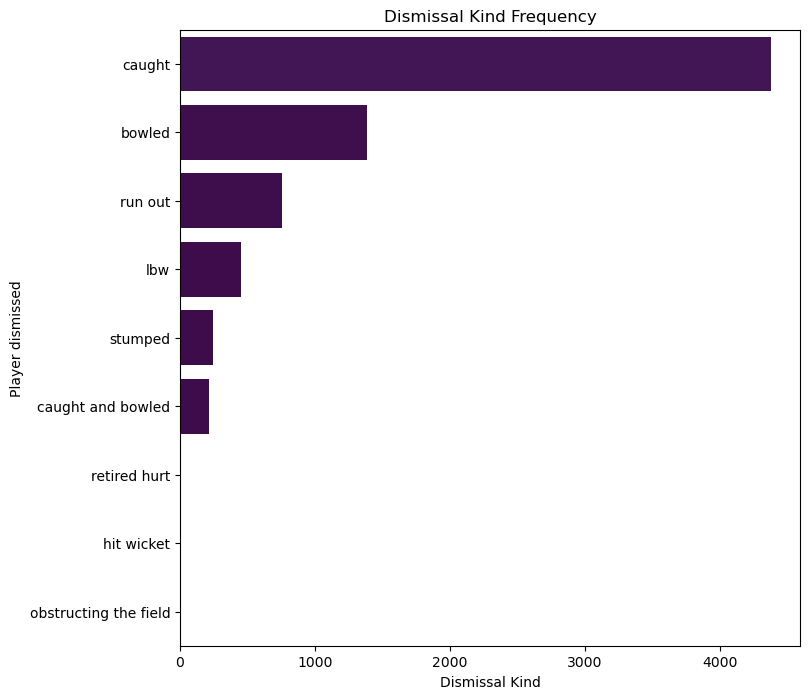

In [206]:

plt.figure(figsize=(8,8))
sea.barplot(data=dismissal_kinds_frequency, y='dismissal_kind', x='count', hue='count', palette='viridis',legend=False)    
plt.xlabel("Dismissal Kind")
plt.ylabel("Player dismissed")
plt.title("Dismissal Kind Frequency")
plt.show()

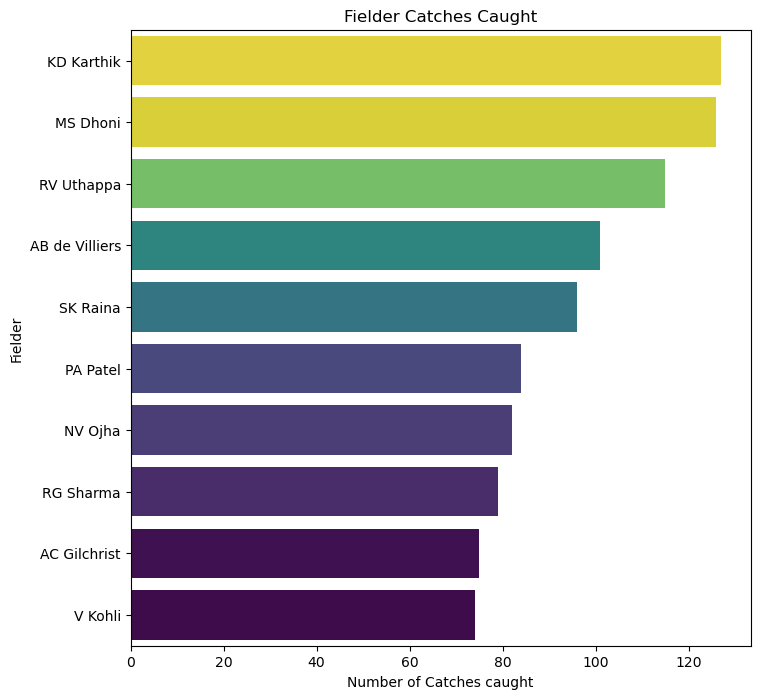

In [207]:
# fielder_who_caught_most_balls

plt.figure(figsize=(8,8))
sea.barplot(data=fielder_who_caught_most_balls.head(10), y='fielder', x='count', hue='count', palette='viridis',legend=False)    
plt.xlabel("Number of Catches caught")
plt.ylabel("Fielder")
plt.title("Fielder Catches Caught")
plt.show()

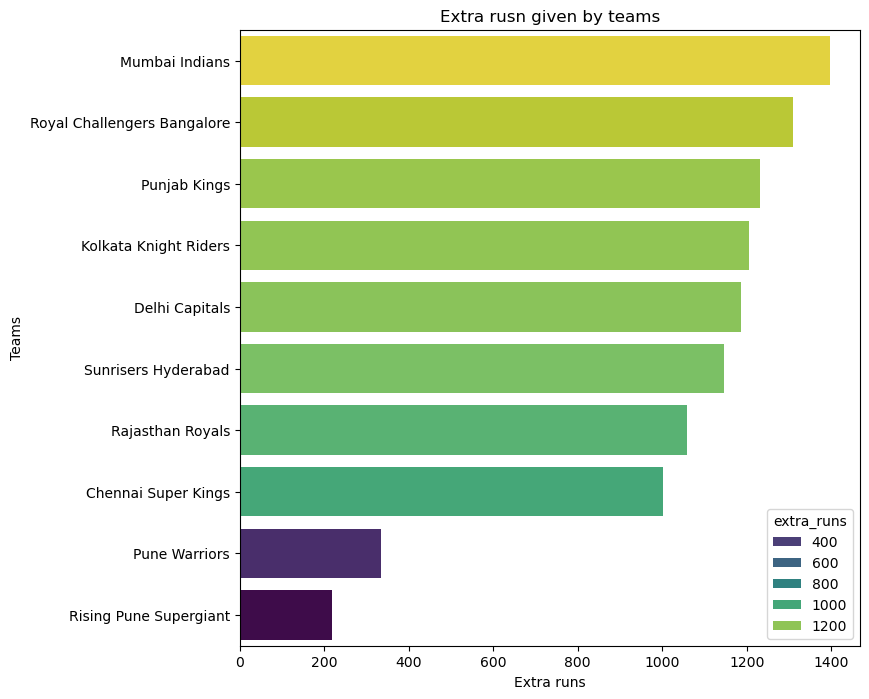

In [208]:
# teams_extra_runs

plt.figure(figsize=(8,8))
sea.barplot(data=teams_extra_runs.head(10), x='extra_runs',y='bowling_team', hue='extra_runs',palette='viridis')
plt.title("Extra rusn given by teams")
plt.xlabel("Extra runs")
plt.ylabel("Teams")
plt.show()

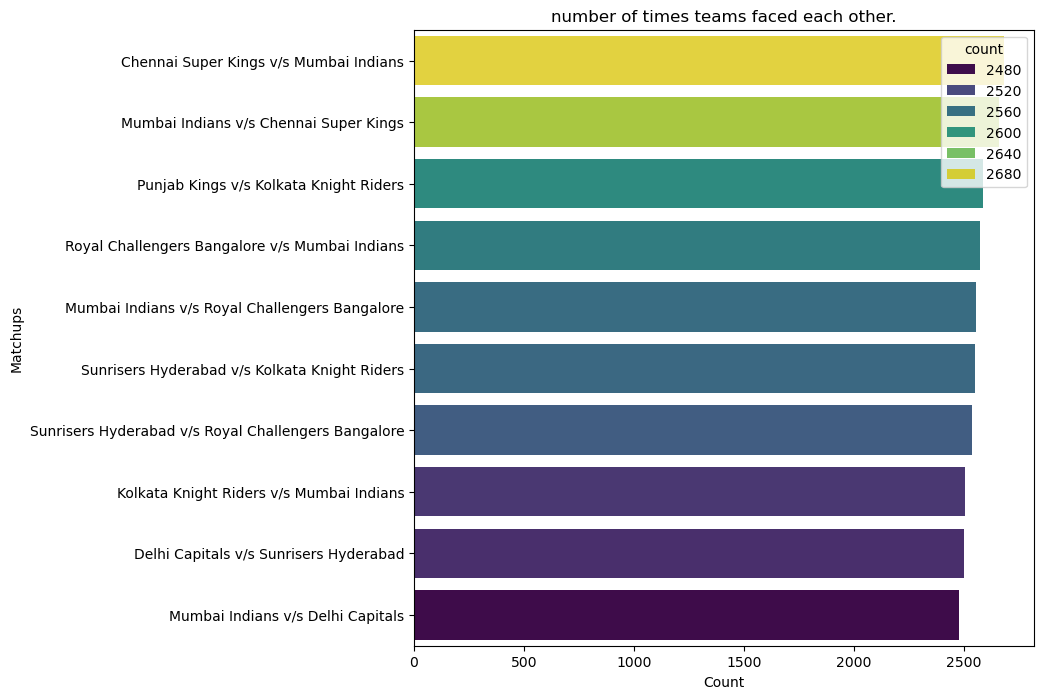

In [209]:
# all_matchups

plt.figure(figsize=(8,8))
sea.barplot(data=all_matchups.head(10), x='count',y='Matchups', hue='count',palette='viridis')
plt.title("number of times teams faced each other.")
plt.xlabel("Count")
plt.ylabel("Matchups")
plt.show()

## Bowler Performance Analysis

Analysing the `bowler_stats.csv` in detail to take out valuable information from the dataset created: this will help us analyse the bowlers based on various stats, and at last help us determine the elite bowler in IPL history.

In [210]:
df = pd.read_csv('bowler_stats.csv')

display(df.shape)
display(df.info())


(356, 20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           356 non-null    int64  
 1   bowler               356 non-null    object 
 2   runs_conceded        356 non-null    int64  
 3   balls bowled         356 non-null    int64  
 4   wide_runs            356 non-null    int64  
 5   noball_runs          356 non-null    int64  
 6   bye_runs             356 non-null    int64  
 7   legbye_runs          356 non-null    int64  
 8   penalty_runs         356 non-null    int64  
 9   extra_runs           356 non-null    int64  
 10  no_of_wickets        356 non-null    int64  
 11  bowling_average      356 non-null    float64
 12  matches_played       356 non-null    int64  
 13  no_of_overs          356 non-null    int64  
 14  dot balls            356 non-null    int64  
 15  four_plus_wickets    356 non-null    int

None

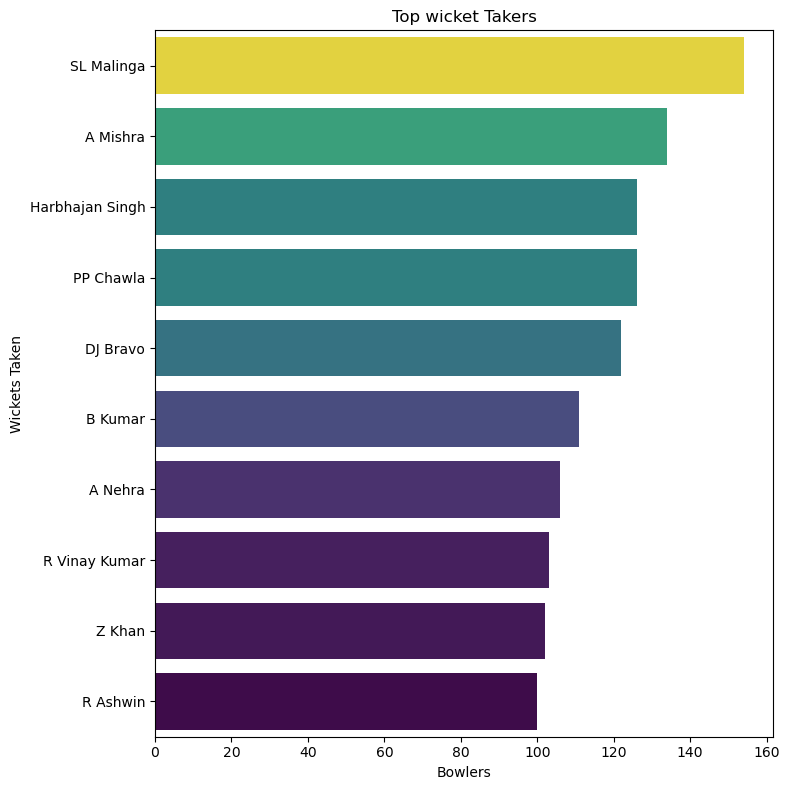

In [211]:
## 1. Who are top wicket takers in IPL.

top_wicket_taking_bowlers = df.sort_values(by='no_of_wickets', ascending=False)
# display(top_10_bowlers)

plt.figure(figsize=(8,8))
sea.barplot(x = 'no_of_wickets',y='bowler', data=top_wicket_taking_bowlers.head(10), hue='no_of_wickets', palette='viridis', legend=False)
plt.xlabel("Bowlers")
plt.ylabel("Wickets Taken")
plt.title("Top wicket Takers")
plt.tight_layout()
plt.show()

Lasith Malinga, A Nehra and Harbhajan Singh and PP Chawla are the top 3 bowlers with most wickets from IPL 2008 to 2019. Which tells us they were key wicket takers for their team.

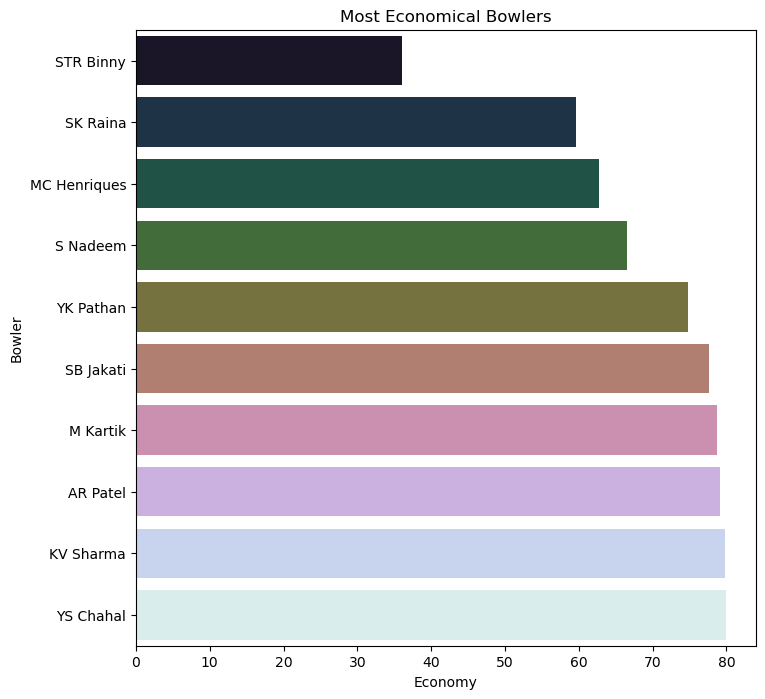

In [212]:
## 2. Who are the most economical bowlers?

top_economical_bowlers = df.sort_values(by='bowling_economy', ascending=True)
top_economical_bowlers = top_economical_bowlers[top_economical_bowlers['matches_played'] >50]
plt.figure(figsize=(8,8))
sea.barplot(x='bowling_economy', y='bowler', hue='bowler', data= top_economical_bowlers.head(10), palette='cubehelix',legend=False)    
plt.xlabel("Economy")
plt.ylabel("Bowler")
plt.title("Most Economical Bowlers")
plt.show()

For bowlers a lower economy rate is preffered average number of runs a bowler conceeds for a over. 

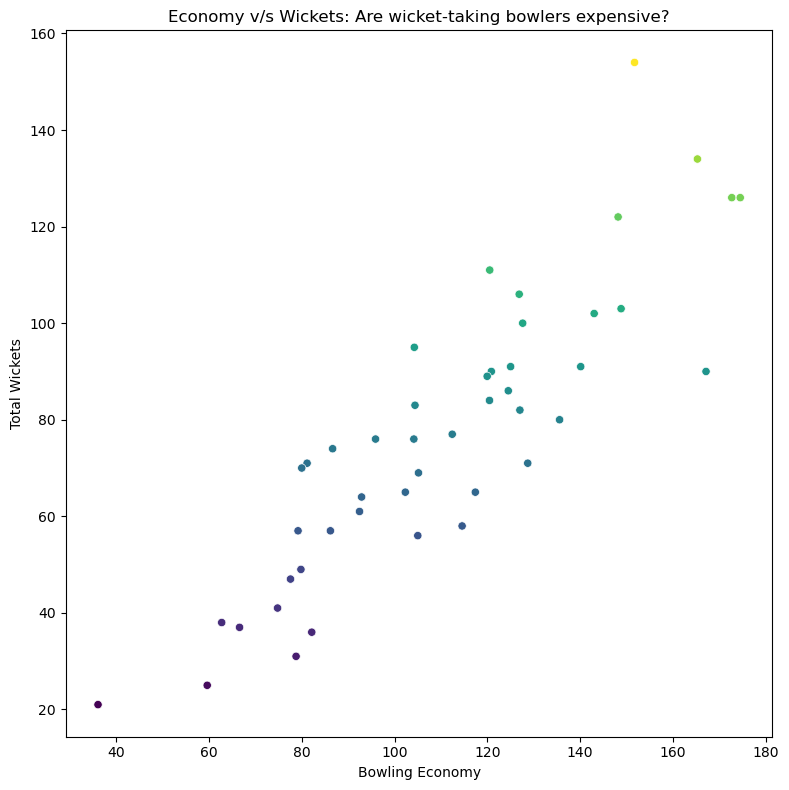

In [213]:
 # Q3. Are the wicket taking bowlers expensive?
data_for_plot = df[df['matches_played'] >= 50]
plt.figure(figsize=(8,8))
sea.scatterplot(data= data_for_plot, x='bowling_economy', y='no_of_wickets', hue='no_of_wickets',palette='viridis', legend=False)
plt.title("Economy v/s Wickets: Are wicket-taking bowlers expensive?")
plt.xlabel("Bowling Economy")
plt.ylabel("Total Wickets")
plt.tight_layout()
plt.show()

The above plot shows us the if the wicket taking bowlers are expensive or not, and as per my understanding we can see how number of wickets led to increase in bwoling economy as well.

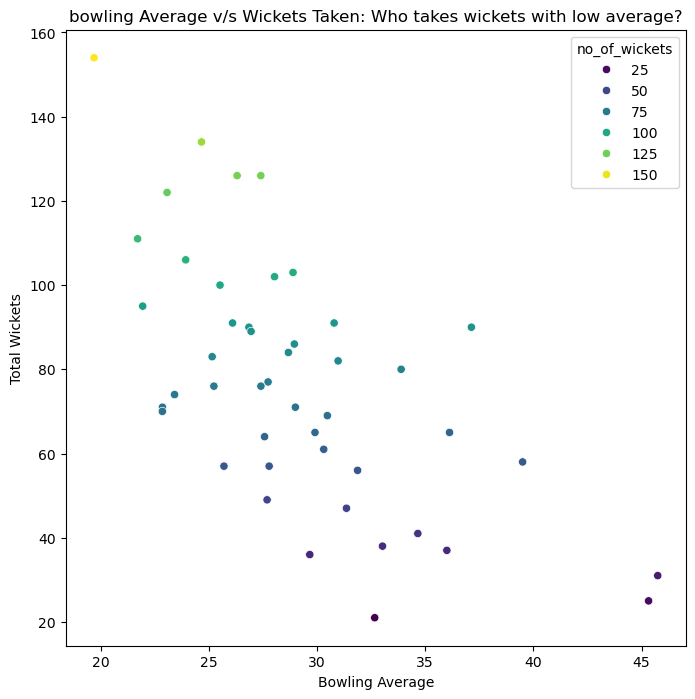

In [214]:
# Q4. Who are the most consistent bowlers.
data_for_plot = df[df['matches_played'] >= 50]
plt.figure(figsize=(8,8))
sea.scatterplot(data=data_for_plot, x='bowling_average', y='no_of_wickets', hue='no_of_wickets', palette='viridis', legend=True)
plt.xlabel("Bowling Average")
plt.ylabel("Total Wickets")
plt.title("bowling Average v/s Wickets Taken: Who takes wickets with low average?")
plt.show()

In Cricket:A lower average is better. The bowling average represents how many runs a bowler concedes per wicket taken. The fewer runs they give up to take a wicket, the more effective they are. A world-class bowler typically aims for an average under 30

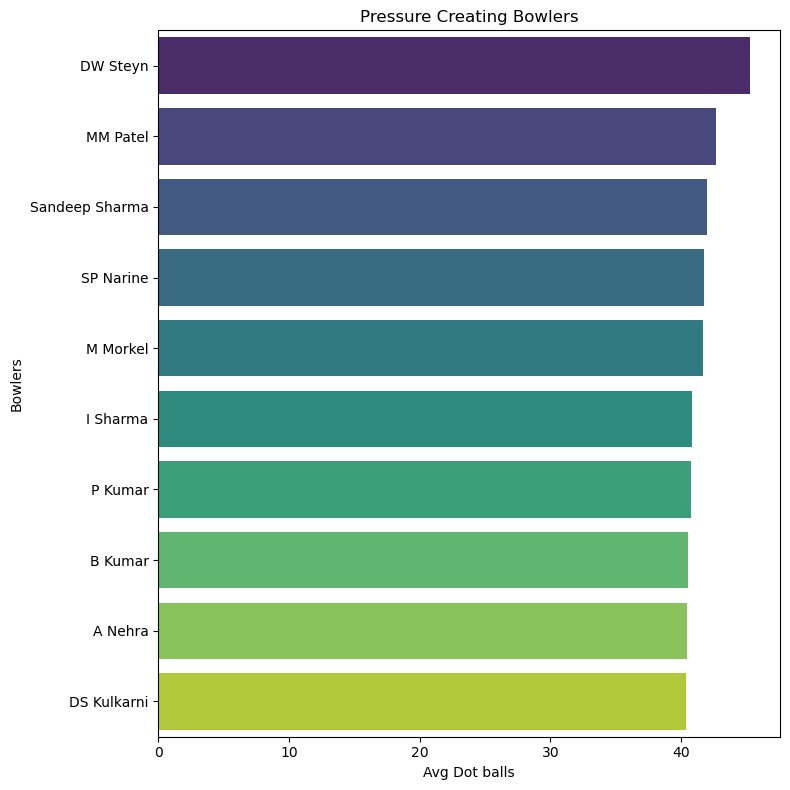

In [215]:
# Q5. Who creates most pressure?
data_for_plot = df[df['matches_played'] >= 50].sort_values(by='average_dot_balls', ascending=False)
plt.figure(figsize=(8,8))
sea.barplot(data=data_for_plot.head(10), x='average_dot_balls', y='bowler', hue='bowler', legend=False, palette='viridis')
plt.title("Pressure Creating Bowlers")
plt.xlabel("Avg Dot balls")
plt.ylabel("Bowlers")
plt.tight_layout()
plt.show()

Bowlers enitre job is to take wickets or stop batsman from scoring and the above plot tells us: how many dot balls were bowled by bowlers and who are the top 10s who create most pressure

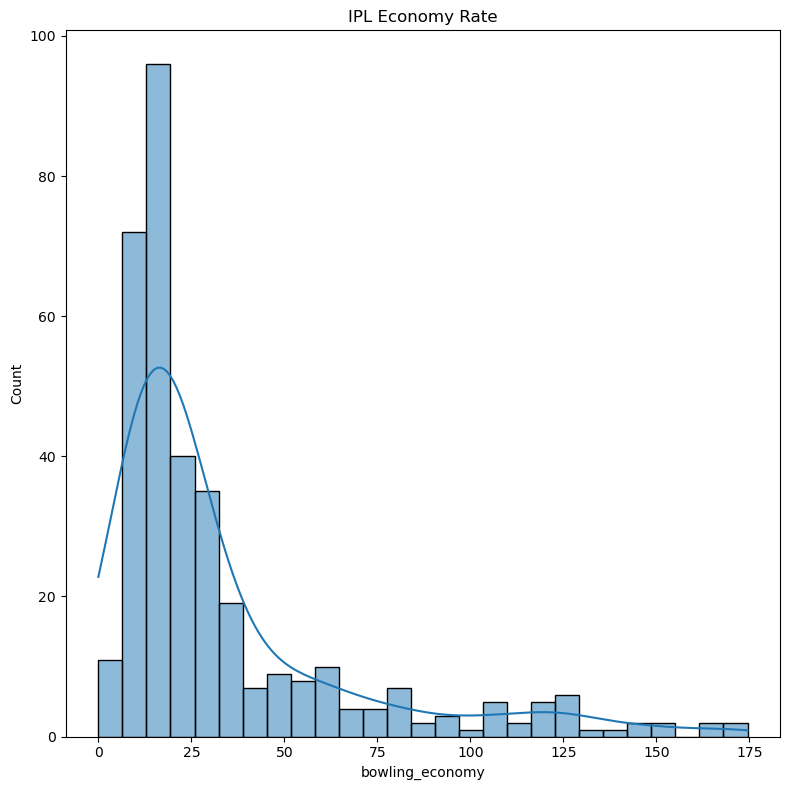

In [216]:
# Q6. Distribution of bowling economy

plt.figure(figsize=(8,8))
sea.histplot(data=df, x='bowling_economy', kde=True)
plt.title("IPL Economy Rate")
plt.xlabel("bowling_economy")
plt.tight_layout()
plt.show()

The data shows a high frequency of lower economy rates, with a peak count near the 15-20 range

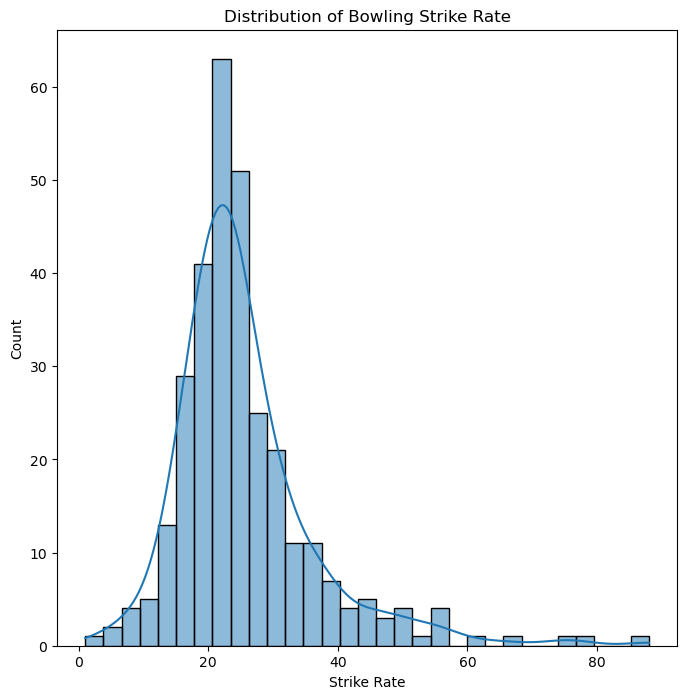

In [217]:
# Q7. Distribution of bowling Strike rate
plt.figure(figsize=(8,8))
sea.histplot(data=df, x='bowling_strike_rate',kde=True)
plt.title("Distribution of Bowling Strike Rate")
plt.xlabel("Strike Rate")
plt.show()

the distribution tells us the frequency of strike rateis between 20-25

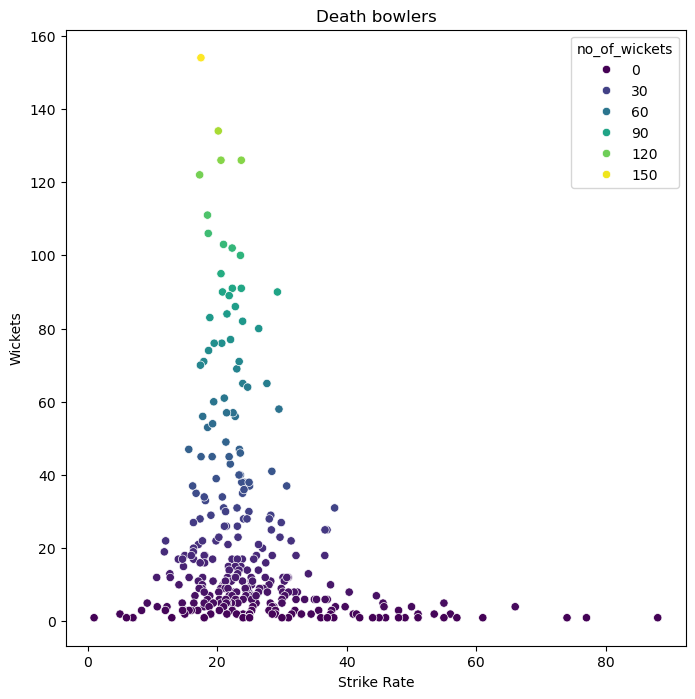

In [218]:
# Q8. Who are the best death/strike bowlers
plt.figure(figsize=(8,8))
sea.scatterplot(data=df, x='bowling_strike_rate', y='no_of_wickets', hue='no_of_wickets', palette='viridis')
plt.title("Death bowlers")
plt.xlabel("Strike Rate")
plt.ylabel("Wickets")
plt.show()

In [219]:
This graphs tells us how much strike rate each bowlers has based on the wickets taking.

SyntaxError: invalid syntax (741109239.py, line 1)

In [ ]:
# Q9. Which bowlers take the most 4+ wickets haulabs
plt.figure(figsize=(8,8))
sea.barplot(data=df.sort_values(by='four_plus_wickets', ascending=False).head(10), x='four_plus_wickets',y='bowler',hue='bowler', palette='viridis')
plt.title("4+ wicket haul bowlers")
plt.xlabel("4+ Wickets Frequency")
plt.ylabel("Bowler")
plt.show()

4+ Wicket taking bowlers: SP Narine SL Maling and RA Jadeja rank highest.

In [ ]:
elite_bowlers = df.copy()

elite_bowlers = elite_bowlers[elite_bowlers['matches_played'] >= 50]

## Normalising:abs

elite_bowlers['wicket_score'] = (elite_bowlers['no_of_wickets'] - 
                                 elite_bowlers['no_of_wickets'].min()
                                )/(
                                    elite_bowlers['no_of_wickets'].max() - 
                                    elite_bowlers['no_of_wickets'].min())

elite_bowlers['dot_score'] = (
    elite_bowlers['average_dot_balls'] -
    elite_bowlers['average_dot_balls'].min()
) / (
    elite_bowlers['average_dot_balls'].max() -
    elite_bowlers['average_dot_balls'].min()
)

elite_bowlers['economy_score'] = (
    elite_bowlers['bowling_economy'].max() -
    elite_bowlers['bowling_economy']
) / (
    elite_bowlers['bowling_economy'].max() -
    elite_bowlers['bowling_economy'].min()
)



elite_bowlers['elite_score'] = (
    elite_bowlers['wicket_score'] * 0.5 +
    elite_bowlers['economy_score'] * 0.3 +
    elite_bowlers['dot_score'] * 0.2
)

elite_bowlers = elite_bowlers.sort_values(
    by='elite_score',
    ascending=False
)

elite_bowlers[['bowler','elite_score']].head(15)

plt.figure(figsize=(10,6))

sea.barplot(
    data=elite_bowlers.head(15),
    x='elite_score',
    y='bowler',
    hue='bowler',
    palette='viridis',
)

plt.title("Elite IPL Bowlers Based on Overall Performance")
plt.show()


Elite bowlers are those bowlers who are analysed by overall elite socre feature engineered by normalization of ceartain selected features and then taken in some percentages.

The heatmap below tells us exactly how two seperate feature correlate with each other.
 Bowling economy and no of wickets have almost near 1 a strong relationship. 
    We can analyse everything by observing the heatmap below.

In [ ]:
# Q11. Correlation Heatmap. 
selected_columns = df[['no_of_wickets', 'bowling_average', 'bowling_economy', 'bowling_strike_rate', 'average_dot_balls', 'matches_played','extra_runs']]
selected_corr = selected_columns.corr()

plt.figure(figsize=(10,6))
sea.heatmap(selected_corr, annot=True, cmap='coolwarm', vmin=1, vmax=1)
plt.show()

In [ ]:
# Q12. Boxplot for outlier detection:
selected_columns = df[['bowling_economy', 'bowling_average', 'bowling_strike_rate']]

plt.figure(figsize=(10,8))
sea.boxplot(selected_columns)
plt.show()

There are a lot of outliers present in economy, average and strike rate but in cricket matches they are totally fine as anything can happen at any point of time in an IPL match, I will capp this outliers when I start normalising features for ML Pipelining data.

In [ ]:
# Q13. Let us check if my cleaned data has any missing values or dupicates.

# display(df.duplicated().sum())
# display(df.isna())
if df.isna().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("## Data quality check: \n")
    print("Missing Values = None\nDuplicates Records = None\nData types verified")
else:
    print("Oh no duplicates/missing values found please remove them")


In [ ]:
df.columns

## Key Insigths:

1. Lasith Malinga is the most consistent and elite bowler in IPL 2008-2019.
2. SP Narine ranks first when it comes to 4+ Wickets Haul.
3. Death bowlers have a tentative strike rate of 15 to 25 range
4. Distibution of ecnomy rate is between 15 - 20 and the frequency distribution of strike rate is between 20-25
5. Outliers found in Bowling Economy, Bowling Average and bowling strike rates.
6. It doesnot matter if you dont take much wickets but what matters is how much pressure you reate on batsman by not giving runs and our dot balls analysis tells that accurately.
7. We also analysed how wicket taking bowlers can be Expensive. 

## Limitations

The above insights are as per my understanding of graphs and overall EDA. The dataset I have is of 2008-2019, which is older hen compared to curent seasons, teams and players dominating the IPL format.

    We also lack player conditions, their peak form and season, also we lack he playing 11 which are the core strength of a team.

## Batsman Performance Analysis

Analysing `batsman_stats.csv` in detail and fetching important insights from the data.

In [ ]:
df = pd.read_csv('batsman_stats.csv')

In [ ]:
# Q1. who are the highest run scorers
df_plot = df.sort_values(by='batsman_runs', ascending=False)

plt.figure(figsize=(8,6))
sea.barplot(data=df_plot.head(10), x='batsman_runs', y='batsman', hue='batsman', legend=False, palette='viridis')
plt.xlabel("Runs Scored")
plt.ylabel("Batsman")
plt.title("Highest Run Scorers")
plt.show()

Sk Raina, V Kohli and RG Sharma are the top 3 IPL Batsman who scored the most runs from 2008-2019.

In [ ]:
# Q2. How are batting averages distributed

plt.figure(figsize=(8,6))
sea.histplot(data=df,x='batting_average', bins=25, kde=True)
plt.title("Batting Average Distribution")
plt.xlabel("Batting Average")
plt.show()

From the distribution: the bowling average distributed is left skewed at its peak between 5-15, rising btw 25-28 and then gradually lowering down

In [ ]:
# Q3. How are the strike rates distributed?
plt.figure(figsize=(8,6))
sea.histplot(data=df, x='strike_rate', bins=25, kde=True)
plt.title("Strike Rate Distribution")
plt.xlabel("Strike Rate")
plt.show()

In [ ]:
The strike rate distribution is distributed heavily in the center of the range, 100 - 135 is the ideal range.

In [ ]:
df['batting_average']

In [ ]:
# Q4. Do high run scorers are also consistent?
plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='batsman_runs', y='batting_average', legend=True)
plt.title("Are high run scorers consistent?")
plt.xlabel("Batsman Runs")
plt.ylabel(" Batting Average")
plt.show()

In [ ]:
# Q5. Who are the most destructive batsmen?abs

plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='strike_rate', y='batsman_runs', legend=True)
plt.title("Who are the most destructive batsman?")
plt.xlabel("strike rate")
plt.ylabel("Runs")
plt.show()

From this graph we can see the Highest runs are scored with a strike rate of 120 - 150 range by the batsman

In [ ]:
# Q6. Boundary dependent batsmans
df_plot = df[df['matches_played'] >= 50].sort_values(by='boundary_percentage', ascending=False)
plt.figure(figsize=(8,6))
sea.barplot(data=df_plot.head(15), x='boundary_percentage', y='batsman',hue='batsman', palette='coolwarm',legend=False)
plt.title("Boundary Dependent Batsman")
plt.xlabel("Boundary Percenatge")
plt.ylabel("Batsman")
plt.show()

Boundary dependent batsman stands for the heavy hitters who try to score runs using the boundary lines (4s or 6s) instead of playing 1 run at a tme they tend tobe hard hitters.

In [ ]:
# Q7. Who converts starts into big innings.abs

df_plot = df[df['matches_played'] >= 50].sort_values(by='no_of_100s', ascending=False)

plt.figure(figsize=(8,6))
sea.barplot(data=df_plot.head(10), x='no_of_100s', y='batsman',hue='batsman',palette='cubehelix')
plt.title("Big Innings capable Batsman")
plt.xlabel("Number of Centuries")
plt.ylabel("Batsman")
plt.show()

These are the batsman which are capable of converting starts into grand endings: Chris Gayle, Virat Kohli and AB de Villers are the top 3 Hundred hitting Mahcines. They are the most consistent batsman too, three of them representing RCB.

In [ ]:
# Q8. Average vs Strike Rate

plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='batting_average', y='strike_rate', hue='strike_rate', palette='viridis')
plt.title("Average vs Strike rate")
plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.show()

Th above scatter plot beautifully shows us how atting average and stike rates are scattered, it answers questions like what is the average when strike rate is 100..

In [ ]:
# Q9. 50s vs 100sabs
plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='no_of_50s', y='no_of_100s', palette= 'viridis', hue='no_of_100s')
plt.title("50's vs 100s")
plt.xlabel("Number of 50s")
plt.ylabel("Number of 100s")
plt.show()

The above graph answers the question of how batsman are efficient when converting 50s to 100s and usingit to greatly set runs or finish a match.

In [ ]:
# Q10. Elite Batsman Scores.

elite_batsman = df.copy()

elite_batsman = elite_batsman[elite_batsman['matches_played']>= 50]

#normalising batsman_runs
# batting_average
# strike_rate
# boundary_percentage

elite_batsman['batsman_runs_score'] = (elite_batsman['batsman_runs'] - elite_batsman['batsman_runs'].min()
                                      ) / (elite_batsman['batsman_runs'].max() - elite_batsman['batsman_runs'].min())

elite_batsman['batsman_average_score'] = (elite_batsman['batting_average'] - elite_batsman['batting_average'].min()
                                      ) / (elite_batsman['batting_average'].max() - elite_batsman['batting_average'].min())

elite_batsman['strike_rate_score'] = (elite_batsman['strike_rate'] - elite_batsman['strike_rate'].min()
                                      ) / (elite_batsman['strike_rate'].max() - elite_batsman['strike_rate'].min())

elite_batsman['boundary_percentage_score'] = (elite_batsman['boundary_percentage'] - elite_batsman['boundary_percentage'].min()
                                      ) / (elite_batsman['boundary_percentage'].max() - elite_batsman['boundary_percentage'].min())

elite_batsman['elite_score'] = (elite_batsman['batsman_runs_score'] * 0.5 +
                                elite_batsman['batsman_average_score']*0.4 +
                                elite_batsman['strike_rate_score']*0.4 +
                                elite_batsman['boundary_percentage_score']*0.3)

elite_batsman = elite_batsman.sort_values(by='elite_score', ascending=False)

elite_batsman[['batsman','elite_score']].head(15)

plt.figure(figsize=(10,8))
sea.barplot(data=elite_batsman.head(15), x='elite_score', y='batsman', hue='batsman', palette='viridis',)
plt.title("Elite IPL Batsmans Based on overall performance")
plt.show()

The elite score of batsman: Elite batsmans are those batsmans who are analysed by overall elite socre feature engineered by normalization of certain selected features and then taken in some percentages.

In [ ]:
# Q11. Correlation heatmaps

selected_columns = df[['batsman_runs',
                        'batting_average',
                        'strike_rate',
                        'boundary_percentage',
                        'no_of_50s',
                        'no_of_100s']]

selected_corr = selected_columns.corr()

plt.figure(figsize=(10,8))
sea.heatmap(data=selected_corr,annot=True,cmap='RdBu',vmin=1,vmax=1)
plt.show()

This above heatmap tells us how two variables are related to each other, I seeno negative correlation btw the variables;
No of 50s and batsman runs have the highest correlation 0.96 whcih means the g=high 50s means high total runs too.

In [ ]:
df_boxplot = df[['batting_average', 'strike_rate']]
df_plot = df['batsman_runs']
plt.figure(figsize=(8,6))
sea.boxplot(data=df_boxplot)
plt.show()

plt.figure(figsize=(8,6))
sea.boxplot(data=df_plot)
plt.show()

We can see outliers in three features, we will capp them wehn we will normalise the data for ML Pipeline.

In [ ]:
# key Insights.


### Limitations
The above insights are as per my understanding of graphs and overall EDA. The dataset I have is of 2008-2019, which is older hen compared to curent seasons, teams and players dominating the IPL format.

    We also lack player conditions, their peak form and season, also we lack he playing 11 which are the core strength of a team.


In [ ]:
df.columns


## Matches Dataset Analysis:

This is the second dataset we are going to analyse: it contains the information of the matches played and the winner.

The dataset has following features:

1. `id`: stands for match_id.
2. `season`: the season in which the match was played.
3. `city`: the city which hosted the match.
4. `team1 and team2`: respectively representing the hometeam and awayteam which played the match.
5. `date`: they day of the match
6. `toss_winner` and `toss_decision`: who won the toss and what they chose to do first (field/bat)
7. `result`: the result of the match if it was normal or if DL was applied
8. `dl_applied`: 1 if dl was applied else 0
9. `winner`: match winning team
10. `win_by_runs` and `win_by_wickets`: tells us whcih team won by runs means bowling team won and by wickets means batting tam won.
11. `player_of_match`: the outstanding player who either bowled or batted hevlity taking wickets and scoring runs for their team in that match
12. `venue`: the stadium on which the match was played
13. `umpire 1, umpire 2 and umpire 3`: The umpires of that particular match


In [ ]:
dataset = pd.read_csv("matches.csv")

In [ ]:
display(dataset.head(4))

display(dataset.info())

In [ ]:
display(df.describe())

In [ ]:
display(dataset.isna().sum())

In [ ]:
match_dataset = dataset.copy()

match_dataset.columns

Filling in the missing values of umpire 1 and 2 with mode and unpire3 with a str of 'umpire3'.

4 matches were cancelled due to rain therefore the situation was a tie and no player of the match was chosen.

We have 7 mising values inn the city column which I filled in by taking a look at the venue came to knwo the stadium is in Dubai so filled th missing values with 'Dubai'.

In [ ]:
umpire1_mode = match_dataset['umpire1'].mode()[0]
umpire2_mode = match_dataset['umpire2'].mode()[0]


match_dataset['umpire1'] = match_dataset['umpire1'].fillna(umpire1_mode) # reassgn
match_dataset['umpire2'] = match_dataset['umpire2'].fillna(umpire2_mode)
match_dataset['umpire3'] = match_dataset['umpire3'].fillna("umpire3")



## I went over the injternet and found that 4 matches were cancelled due to rain so that is the main reason for NaN in winner and POTM.abs

match_dataset['player_of_match'] = match_dataset['player_of_match'].fillna("N/A")
match_dataset['winner'] = match_dataset['winner'].fillna("tie")

display(match_dataset.isna().sum())

# Filling missing city values
display(match_dataset[match_dataset['city'].isna()])

match_dataset['city'] = np.where(match_dataset['venue'] == 'Dubai International Cricket Stadium',
                                 match_dataset['city'].fillna('Dubai'), match_dataset['city'])
display(match_dataset[match_dataset['city'].isna()])

display(match_dataset.isna().sum())

Standardized the team names to avoid duplicates and so that the team represents the current team name. and filled the city names so they match each other.

In [ ]:
team_name_mapp = {
                  'Rising Pune Supergiants' : 'Rising Pune Supergiant',
                  'Rising Pune Supergiats' : 'Rising Pune Supergiant',
                  'Delhi Daredevils':'Delhi Capitals',
                  'Deccan Chargers':'Sunrisers Hyderabad'
}

city_mapp= {
    "Bengaluru":"Bangalore"
}

def standardize_city_names(df, columns):
    for col in columns:
        df[col] = df[col].replace(city_mapp)
    return df

def standardize_team_names(df,columns):
  for col in columns:
    df[col] = df[col].replace(team_name_mapp)
  return df

team_columns =['team1','team2','toss_winner','winner']
match_dataset= standardize_team_names(match_dataset,team_columns)

city_column = ['city']
match_dataset = standardize_city_names(match_dataset, city_column)

In [ ]:
# match_dataset['city'].value_counts()

In [ ]:
match_dataset['team1'].value_counts()

In [ ]:
# matches_dataset = match_dataset.to_csv("cleaned_matches.csv")


## EDA ON MATCHES_DATASET

analysing the matches dataset, after cleaning to find out key insights and analysing graphs

In [ ]:
# Q1. Which teams have won most matchesin IPL

df_plot = match_dataset['winner'].value_counts().reset_index()

df_plot = df_plot[df_plot['winner'] != 'N/A']

display(df_plot)

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot, x='count', y='winner', hue='winner', palette='cubehelix', legend=False)
plt.title("Most IPL matches winning team")
plt.xlabel("matches won")
plt.ylabel("Teams")
plt.show()

Mumbai Indians: won the most matches followed by CSK, KKR and SRH.

In [ ]:
# Q2. Which venue has hosted the most matches in IPl.abs

df_plot = match_dataset['venue'].value_counts().reset_index()

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot.head(10), x='count', y='venue',hue='venue', palette='viridis', legend=False)
plt.title("Most played venues")
plt.xlabel("Matches Played")
plt.ylabel("Venues")
plt.show()

In [ ]:
It answers the question: Where were most IPL matches played.

In [ ]:
# Q3. Which cities has hosted most matches

df_plot = match_dataset['city'].value_counts().reset_index()

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot.head(11), x='count', y='city', hue='city', palette='RdBu', legend=False)
plt.title("Most match hosted cities")
plt.xlabel("MAtches Hosted")
plt.ylabel("Cities")
plt.show()

Mumbai, Banglore and kolkata hosted most of the matches played in the IPL.

In [ ]:
# Q4. Does toss winning actually help?

match_dataset['toss_match_win'] = (
    match_dataset['toss_winner'] == match_dataset['winner']
)

plt.figure(figsize=(10,8))
sea.countplot(data=match_dataset, x='toss_match_win', legend=True)
plt.title("Are toss winning teams actually match winning teams?")
plt.xlabel("Toss Winner - Match Winner")
plt.ylabel("Number of Matches")
plt.show()

we can see the True values is slight;y more than the False values which means the myth Toss Win Match WIn is only true in rare cases.

In [ ]:
# better analysis

match_dataset['toss_match_win'].value_counts(normalize=True)*100


In [ ]:
# Q5. What do captains prefer after toss :

plt.figure(figsize=(10,8))
sea.countplot(data=match_dataset, x='toss_decision')
plt.title("What do captains prefer after winning toss")
plt.xlabel("Toss Decisions")
plt.ylabel("Count")
plt.show()


Most captains prefer fielding after winning the toss as per the above graph

This is the graph showing the timeline and matches played from 2008 to 2019, peaking in 2013 with 76 matches.

In [ ]:
# Q6. How many matches were played every season

matches_per_season = match_dataset['season'].value_counts().reset_index().sort_index()



# display(matches_per_season.sort_values(by='season'))


plt.figure(figsize=(10,8))
sea.lineplot(data=matches_per_season.sort_values(by='season'), x='season',y='count',marker='o')
plt.title("Matches Played every Season")
plt.xlabel("Seasons")
plt.ylabel("Matches Played")
plt.show()

In [ ]:
# Q Who won the most POTM award

df_plot = match_dataset['player_of_match'].value_counts().reset_index()

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot.head(15), x='count', y='player_of_match', hue='player_of_match', palette='viridis')
plt.title("Most Player of the match winners")
plt.xlabel("Number of POTM awards")
plt.ylabel("Players")
plt.show()

Chris gayle, AB de Villers and RG Sharma are the top batsman who won the most POTM awards.

In [ ]:
# Q8. How are matches usual
run_margin = match_dataset[match_dataset['win_by_runs'] > 0]

plt.figure(figsize=(8,5))

sea.histplot(
    data=run_margin,
    x='win_by_runs',
    bins=20,
    kde=True
)
plt.title("Distribution of Winning Margin (Runs)")
plt.xlabel({"Run Margin"})
plt.ylabel("Matches won")
plt.show()



wicket_margin = match_dataset[match_dataset['win_by_wickets'] > 0]
plt.figure(figsize=(8,5))
sea.histplot(
    data=wicket_margin,
    x= 'win_by_wickets',
    bins=20,
    kde=True
)
plt.title("Distribution of Winnign Margin (Wickets)")
plt.xlabel("WICKET MARGIN")
plt.ylabel("Matches Won")
plt.show()

In [ ]:
Both of these distributions tells us hwo matches are won usually, by wickets: how many and by run margin: how many runs left.

In [ ]:
# Q9. Which team prefer batting first after winning toss.

data_heatmap = pd.crosstab(
    match_dataset['toss_winner'],
    match_dataset['toss_decision']
)

sea.heatmap(data_heatmap, cmap='coolwarm', annot=True, fmt='g')
plt.show()

This heatmap shows: the number of times a team chose to field and bat after winnig toss.

In [ ]:
# Q10. which team dominate at venues

heatmap_plot = pd.crosstab(
    match_dataset['venue'],
    match_dataset['winner']
)


sea.heatmap(heatmap_plot.head(), cmap='coolwarm', annot=True,fmt='g')
plt.show()

In [ ]:

selected_columns = match_dataset[['dl_applied', "win_by_runs", "win_by_wickets"]]

selected_corr = selected_columns.corr()

plt.figure(figsize=(10,8))
sea.heatmap(data=selected_corr,annot=True,cmap='RdBu',vmin=1,vmax=1)
plt.show()